In [3]:
!pip install category_encoders -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

# Step 1: Ingestion from external source
df = pd.read_csv('/content/Messy_Employee_dataset.csv')

# Preliminary audit of variable data types
print(df.dtypes)

# Quantify null values
print(df.isnull().sum())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.0 MB/s eta 0:00:00
Employee_ID           object
First_Name            object
Last_Name             object
Age                  float64
Department_Region     object
Status                object
Join_Date             object
Salary               float64
Email                 object
Phone                  int64
Performance_Score     object
Remote_Work             bool
dtype: object
Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64


<Axes: >

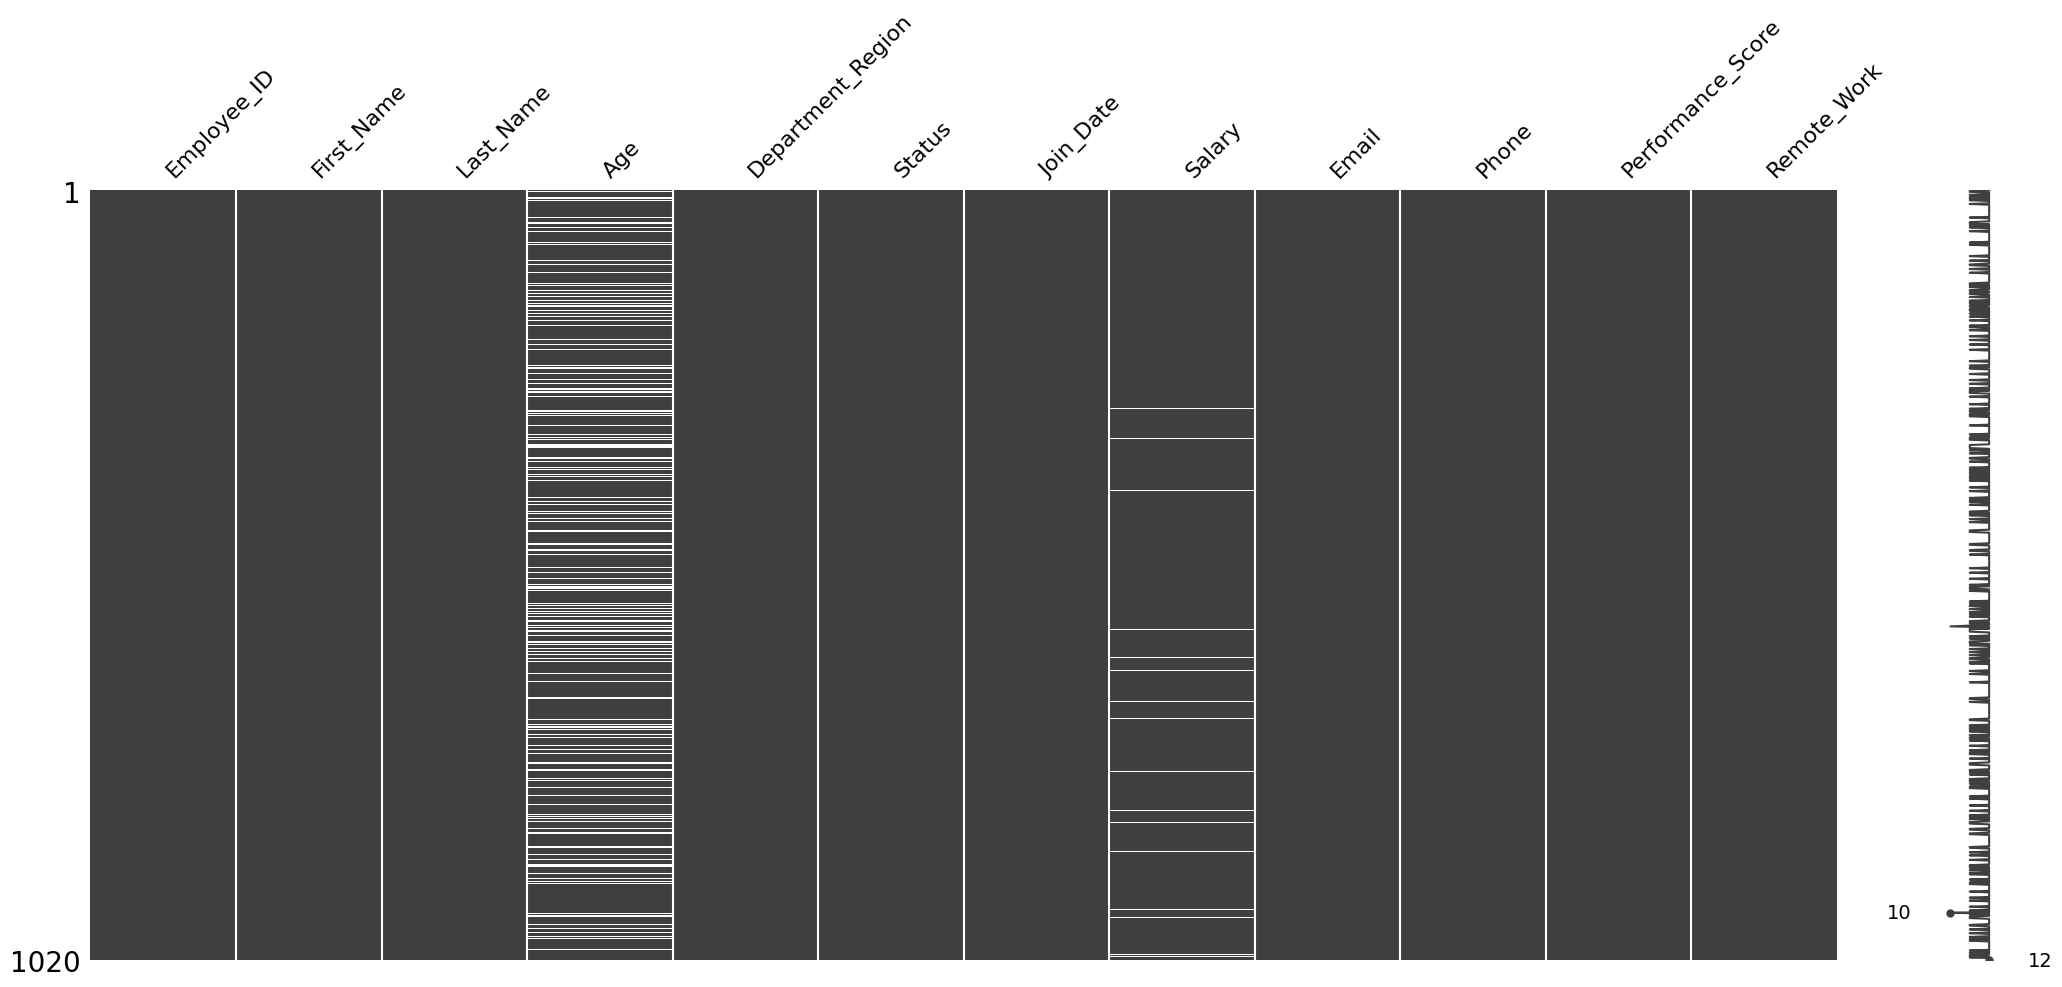

In [4]:
# Step 2: Visual Forensics
msno.matrix(df)

# Instructor Note: Students should visually observe whether missing values
# in 'Age' and 'Salary' show structural alignment across rows.
# If gaps co-occur consistently, this indicates MAR (Missing at Random).
# If gaps appear randomly scattered, this suggests MCAR (Missing Completely at Random).

In [5]:
# Step 3: Grouped Conditional Imputation
# First, extract clean department from 'Department_Region' (e.g. 'DevOps-California' → 'DevOps')
df['Department'] = df['Department_Region'].str.split('-').str[0]

# Imputing the median salary based on department to preserve variance structures
df['Salary'] = df.groupby('Department')['Salary'].transform(lambda x: x.fillna(x.median()))

# Verify no nulls remain in Salary
print(df['Salary'].isnull().sum())

0


In [8]:
# Step 4: The Dummy Variable Trap (Intentional Failure)
dummies_trap = pd.get_dummies(df['Department'], drop_first=False).astype(int)
X_trap = pd.concat([df[['Age']], dummies_trap], axis=1)

# Drop rows where Age is null since we haven't imputed it yet
X_trap = X_trap.dropna()
y = df.loc[X_trap.index, 'Salary']

# Adding the constant intercept creates perfect multicollinearity
X_trap = sm.add_constant(X_trap)

# This will trigger a severe multicollinearity warning or a LinAlgError
model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.304
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0327
Time:                        20:51:46   Log-Likelihood:                -9141.9
No. Observations:                 809   AIC:                         1.830e+04
Df Residuals:                     802   BIC:                         1.833e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.379e+04   3456.991     18.453      0.0

In [9]:
# Step 5: Escaping the Trap (k-1 methodology)
# drop_first=True drops the first department category as the reference class
dummies_safe = pd.get_dummies(df['Department'], drop_first=True).astype(int)
X_safe = pd.concat([df[['Age']], dummies_safe], axis=1)

# Drop rows where Age is null
X_safe = X_safe.dropna()
y = df.loc[X_safe.index, 'Salary']

X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Department_Region has 30+ unique combos — compress into a continuous vector
# representing the average salary per region-department combination
encoder = ce.TargetEncoder(cols=['Department_Region'])
df['department_region_encoded'] = encoder.fit_transform(df['Department_Region'], df['Salary'])

# Verify the encoding
print(df[['Department_Region', 'department_region_encoded']].drop_duplicates().sort_values('department_region_encoded'))

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.304
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0327
Time:                        20:52:21   Log-Likelihood:                -9141.9
No. Observations:                 809   AIC:                         1.830e+04
Df Residuals:                     802   BIC:                         1.833e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        7.47e+04   4308.290     17.338      0.0

In [10]:
# Cell 1 — Install dependencies
!pip install streamlit missingno category_encoders pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.2 MB/s eta 0:00:00


In [11]:
# Cell 2 — Write the app to a file
%%writefile visual_forensics_app.py

import streamlit as st
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# ── Page Configuration ─────────────────────────────────────────────────────────
st.set_page_config(page_title="Visual Forensics Dashboard", page_icon="🔬", layout="wide")

# ── Custom Styling ─────────────────────────────────────────────────────────────
st.markdown("""
    <style>
        @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');
        html, body, [class*="css"] { font-family: 'IBM Plex Sans', sans-serif; }
        h1, h2, h3 { font-family: 'IBM Plex Mono', monospace; }
        .metric-card {
            background: #1c1f26; border: 1px solid #2e3340;
            border-left: 3px solid #00e5ff; border-radius: 6px;
            padding: 1rem 1.25rem; margin-bottom: 0.5rem;
        }
        .metric-card h4 { color: #00e5ff; font-family: 'IBM Plex Mono', monospace;
            font-size: 0.75rem; margin: 0 0 0.25rem 0;
            text-transform: uppercase; letter-spacing: 0.1em; }
        .metric-card p { color: #f0f2f5; font-size: 1.5rem; font-weight: 600; margin: 0; }
        .stButton > button {
            background-color: #00e5ff; color: #0e1117;
            font-family: 'IBM Plex Mono', monospace; font-weight: 600;
            border: none; border-radius: 4px; padding: 0.5rem 1.5rem; width: 100%;
        }
        .section-header { font-family: 'IBM Plex Mono', monospace; color: #00e5ff;
            font-size: 0.7rem; text-transform: uppercase; letter-spacing: 0.15em;
            border-bottom: 1px solid #2e3340; padding-bottom: 0.5rem; margin-bottom: 1rem; }
        .success-box { background: #0d2b1f; border: 1px solid #00c853; border-radius: 6px;
            padding: 0.75rem 1rem; color: #69f0ae; font-family: 'IBM Plex Mono', monospace; font-size: 0.85rem; }
    </style>
""", unsafe_allow_html=True)

# ── Header ─────────────────────────────────────────────────────────────────────
st.markdown("# 🔬 Visual Forensics Dashboard")
st.markdown("*Diagnose missingness structure · Execute conditional imputation · Inspect results*")
st.markdown("---")

# ── SESSION STATE ──────────────────────────────────────────────────────────────
# st.session_state persists variables across reruns. Every widget interaction
# triggers a full script rerun — session_state "pins" the DataFrame in memory
# so it isn't lost each time the user clicks a button.
if 'df_original' not in st.session_state:
    st.session_state.df_original = None
if 'df_imputed' not in st.session_state:
    st.session_state.df_imputed = None
if 'imputation_log' not in st.session_state:
    st.session_state.imputation_log = []

# ── ST.CACHE_DATA ──────────────────────────────────────────────────────────────
# @st.cache_data memoizes the function output keyed to its inputs.
# The CSV is only parsed once — subsequent reruns return the cached DataFrame
# instantly, avoiding redundant I/O on every button click or widget change.
@st.cache_data
def load_data(file):
    return pd.read_csv(file)

# ── STEP 1: File Upload ────────────────────────────────────────────────────────
st.markdown('<p class="section-header">① Upload Dataset</p>', unsafe_allow_html=True)
uploaded_file = st.file_uploader("Drop your CSV here", type=["csv"])

if uploaded_file:
    st.session_state.df_original = load_data(uploaded_file)
    if st.session_state.df_imputed is None:
        st.session_state.df_imputed = st.session_state.df_original.copy()

if st.session_state.df_original is not None:
    df_orig = st.session_state.df_original
    df      = st.session_state.df_imputed

    # ── STEP 2: Dataset Overview ───────────────────────────────────────────────
    st.markdown('<p class="section-header">② Dataset Overview</p>', unsafe_allow_html=True)
    null_counts     = df.isnull().sum()
    null_pct        = (null_counts / len(df) * 100).round(1)
    cols_with_nulls = (null_counts > 0).sum()
    total_null_pct  = round(df.isnull().sum().sum() / df.size * 100, 2)

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown(f'<div class="metric-card"><h4>Rows</h4><p>{df.shape[0]:,}</p></div>', unsafe_allow_html=True)
    with c2:
        st.markdown(f'<div class="metric-card"><h4>Columns</h4><p>{df.shape[1]}</p></div>', unsafe_allow_html=True)
    with c3:
        st.markdown(f'<div class="metric-card"><h4>Cols w/ Nulls</h4><p>{cols_with_nulls}</p></div>', unsafe_allow_html=True)
    with c4:
        st.markdown(f'<div class="metric-card"><h4>Total Null %</h4><p>{total_null_pct}%</p></div>', unsafe_allow_html=True)

    null_df = pd.DataFrame({
        'Column': null_counts.index, 'Null Count': null_counts.values,
        'Null %': null_pct.values,   'Dtype': df.dtypes.astype(str).values
    }).sort_values('Null Count', ascending=False)
    st.dataframe(null_df, use_container_width=True, hide_index=True)
    st.markdown("---")

    # ── STEP 3: Missingness Matrix ─────────────────────────────────────────────
    st.markdown('<p class="section-header">③ Missingness Matrix — Structural Diagnosis</p>', unsafe_allow_html=True)
    col_left, col_right = st.columns([2, 1])

    with col_left:
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor('#1c1f26')
        ax.set_facecolor('#1c1f26')
        msno.matrix(df, ax=ax, color=(0.0, 0.9, 1.0), fontsize=10, sparkline=True)
        ax.tick_params(colors='#aab0bc')
        st.pyplot(fig)
        plt.close()

    with col_right:
        st.markdown("#### How to Read This")
        st.markdown("""
        - **Dark bars** = data present
        - **White gaps** = missing values
        - **Aligned gaps** → **MAR** (Missing at Random)
        - **Scattered gaps** → **MCAR** (Missing Completely at Random)
        - **Systematic blocks** → **MNAR** (Missing Not at Random)
        """)
        st.markdown("#### Null % by Column")
        for _, row in null_df[null_df['Null Count'] > 0].iterrows():
            st.markdown(f"`{row['Column']}` — **{row['Null %']}%**")
            st.progress(int(row['Null %']))

    st.markdown("---")

    # ── STEP 4: Conditional Imputation ────────────────────────────────────────
    st.markdown('<p class="section-header">④ Conditional Median Imputation</p>', unsafe_allow_html=True)
    numeric_cols  = df.select_dtypes(include='number').columns.tolist()
    category_cols = df.select_dtypes(include=['object']).columns.tolist()
    null_numeric  = [c for c in numeric_cols if df[c].isnull().any()]

    if not null_numeric:
        st.markdown('<div class="success-box">✓ No numeric nulls remain — imputation already complete.</div>', unsafe_allow_html=True)
    else:
        imp_col1, imp_col2 = st.columns(2)
        with imp_col1:
            target_col = st.selectbox("Select numeric column to impute", options=null_numeric)
        with imp_col2:
            group_col = st.selectbox("Group by (categorical column)", options=category_cols)

        st.markdown(f"**Strategy:** Fill `{target_col}` nulls with the **median** within each `{group_col}` group.")

        if st.button("▶ Execute Conditional Imputation"):
            df_new = st.session_state.df_imputed.copy()
            before = df_new[target_col].isnull().sum()
            df_new[target_col] = df_new.groupby(group_col)[target_col].transform(
                lambda x: x.fillna(x.median())
            )
            after  = df_new[target_col].isnull().sum()
            filled = before - after
            st.session_state.df_imputed = df_new
            st.session_state.imputation_log.append(f"Filled {filled} nulls in '{target_col}' grouped by '{group_col}'")
            st.rerun()

    if st.session_state.imputation_log:
        st.markdown("#### Imputation Audit Log")
        for entry in st.session_state.imputation_log:
            st.markdown(f'<div class="success-box">✓ {entry}</div>', unsafe_allow_html=True)

    st.markdown("---")

    # ── STEP 5: Before / After + Download ─────────────────────────────────────
    st.markdown('<p class="section-header">⑤ Before vs. After Comparison</p>', unsafe_allow_html=True)
    tab1, tab2, tab3 = st.tabs(["📊 Null Summary", "🔬 Post-Imputation Matrix", "⬇️ Download"])

    with tab1:
        orig_nulls = st.session_state.df_original.isnull().sum()
        new_nulls  = st.session_state.df_imputed.isnull().sum()
        comparison = pd.DataFrame({
            'Column': orig_nulls.index, 'Nulls Before': orig_nulls.values,
            'Nulls After': new_nulls.values, 'Filled': (orig_nulls - new_nulls).values
        })
        st.dataframe(comparison[comparison['Nulls Before'] > 0], use_container_width=True, hide_index=True)

    with tab2:
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        fig2.patch.set_facecolor('#1c1f26')
        ax2.set_facecolor('#1c1f26')
        msno.matrix(st.session_state.df_imputed, ax=ax2, color=(0.2, 1.0, 0.5), fontsize=10)
        ax2.tick_params(colors='#aab0bc')
        st.pyplot(fig2)
        plt.close()

    with tab3:
        csv_bytes = st.session_state.df_imputed.to_csv(index=False).encode('utf-8')
        st.download_button(label="⬇ Download Imputed CSV", data=csv_bytes,
                           file_name="imputed_dataset.csv", mime="text/csv")

else:
    st.markdown("""
    <div style="text-align:center; padding: 4rem 2rem; color: #4a5060;">
        <div style="font-size: 3rem;">🔬</div>
        <div style="font-family: 'IBM Plex Mono', monospace; font-size: 1rem; margin-top: 1rem;">
            Upload a CSV above to begin forensic analysis
        </div>
    </div>
    """, unsafe_allow_html=True)

Writing visual_forensics_app.py


In [ ]:
# Cell 3 — Launch the app using localtunnel (no account required)
import subprocess
import time

# Start the Streamlit server in the background
subprocess.Popen(["streamlit", "run", "visual_forensics_app.py",
                  "--server.port=8501", "--server.headless=true"])

# Give Streamlit a moment to start
time.sleep(3)

# Install and run localtunnel to expose port 8501 publicly
!npm install -g localtunnel -q
!npx localtunnel --port 8501 &

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://ten-zebras-drum.loca.lt


In [15]:
# Cell 4 — Get the tunnel password if prompted
!curl -s https://ipv4.icanhazip.com

34.56.246.128
